# Notebook 09: Constraint Intensity Experiment

## Research Question
*Do the AINN monotonicity constraints have a measurable effect on long-horizon recursive forecasting, even though they are neutral on one-step-ahead RMSE?*

## Motivation
The champion model uses λ_monotonicity = 0.001 (selected by Optuna to minimise RMSE). At this intensity, the constraint has near-zero effect on one-step accuracy (-0.009%). But RMSE is the wrong metric for evaluating structural constraints — they are designed to improve **forecasting stability**, not point accuracy.

This notebook systematically varies λ_monotonicity across 5 levels and measures the effect on:
1. **RMSE** (one-step-ahead cost)
2. **frac(ΔK_t > 0)** (fraction of predictions where mortality worsens — the constraint target)
3. **95% CI width at 2050** (recursive forecasting stability)
4. **Cumulative drift** (systematic shift in the 30-year projection)

If the constraint reduces CI width and drift at the cost of a small RMSE increase, it demonstrates a quantifiable **governance-accuracy trade-off** — the central contribution of the AINN framework.

## Design
- Architecture: LSTM(48,32), lb=15 (champion, fixed)
- λ_coherence: 0.001 (fixed)
- λ_monotonicity: [0.0, 0.001, 0.01, 0.1, 1.0]
- Seed: 42 (single seed, isolates λ effect)
- Forecast: 200 MC Dropout sims, corrected σ (residual-calibrated)
- Metric: CHE Male and Female at 2050 horizon


In [1]:
import sys
sys.path.append('../src')
from reproducibility import set_seed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, logging, warnings, time
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
import joblib

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS
set_style('notebook')

PROCESSED_DIR = '../data/processed/'
MODELS_DIR = '../models/'
FIGURES_DIR = '../reports/figures/'

with open(os.path.join(PROCESSED_DIR, 'li_lee_params.pkl'), 'rb') as f:
    bundle = pickle.load(f)
feature_matrices = bundle['feature_matrices']
common_factors = bundle['common_factors']
YEARS = bundle['metadata']['years']
AGES = bundle['metadata']['ages']

with open(os.path.join(PROCESSED_DIR, 'training_meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

LOOKBACK = meta['lookback']
N_FEATURES = meta['n_features']
TRAIN_SPLIT_IDX = meta['train_split_idx']
BATCH_SIZE = 8
EPOCHS = 150
LR = meta['lr']
U1, U2 = meta['units_l1'], meta['units_l2']
LC = meta['lambda_coherence']  # fixed at 0.001

# Load corrected σ from NB04
with open(os.path.join(PROCESSED_DIR, 'forecasting_assets.pkl'), 'rb') as f:
    assets = pickle.load(f)
sigma_res_male = assets['process_std_male']
sigma_res_female = assets['process_std_female']

LAMBDA_MONOS = [0.0, 0.001, 0.01, 0.1, 1.0]
N_SIMS = 200
N_YEARS = 30

print(f'Architecture: LSTM({U1},{U2}), lb={LOOKBACK}, lr={LR}')
print(f'λ_coherence: {LC} (fixed)')
print(f'λ_monotonicity levels: {LAMBDA_MONOS}')
print(f'Forecast: {N_SIMS} MC Dropout sims, {N_YEARS} years')

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Architecture: LSTM(48,32), lb=15, lr=0.001
λ_coherence: 0.001 (fixed)
λ_monotonicity levels: [0.0, 0.001, 0.01, 0.1, 1.0]
Forecast: 200 MC Dropout sims, 30 years


## 9.1: Data Preparation & Helpers

In [2]:
# Data preparation (from NB03)
def prepare_joint_data(lookback):
    male_data = np.column_stack([feature_matrices['male'], np.zeros(len(feature_matrices['male']))])
    female_data = np.column_stack([feature_matrices['female'], np.ones(len(feature_matrices['female']))])
    train_combined = np.vstack([male_data[:TRAIN_SPLIT_IDX], female_data[:TRAIN_SPLIT_IDX]])
    scaler = StandardScaler()
    scaler.fit(train_combined)
    male_scaled = scaler.transform(male_data)
    female_scaled = scaler.transform(female_data)
    def make_seq(data, lb):
        X, y = [], []
        for i in range(lb, len(data)):
            X.append(data[i-lb:i])
            y.append(data[i])
        return np.array(X), np.array(y)
    X_m, y_m = make_seq(male_scaled, lookback)
    X_f, y_f = make_seq(female_scaled, lookback)
    n_train = TRAIN_SPLIT_IDX - lookback
    X_train = np.concatenate([X_m[:n_train], X_f[:n_train]])
    y_train = np.concatenate([y_m[:n_train], y_f[:n_train]])
    X_val = np.concatenate([X_m[n_train:], X_f[n_train:]])
    y_val = np.concatenate([y_m[n_train:], y_f[n_train:]])
    idx = np.random.permutation(len(X_train))
    X_train, y_train = X_train[idx], y_train[idx]
    return X_train, y_train, X_val, y_val, scaler

class AINNLoss(keras.losses.Loss):
    def __init__(self, lambda_coherence=0.0, lambda_monotonicity=0.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_coherence = lambda_coherence
        self.lambda_monotonicity = lambda_monotonicity
    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        coherence = tf.reduce_mean(tf.square(y_pred[:, 1:7]))
        monotonicity = tf.reduce_mean(tf.square(tf.nn.relu(y_pred[:, 0])))
        return mse + self.lambda_coherence * coherence + self.lambda_monotonicity * monotonicity

def forecast_mcd(model, init_seq, n_steps=N_YEARS, n_sims=N_SIMS):
    n_feat = init_seq.shape[-1]
    sims = np.zeros((n_sims, n_steps, n_feat))
    for s in range(n_sims):
        seq = init_seq.copy()
        for t in range(n_steps):
            inp = tf.convert_to_tensor(seq[np.newaxis, ...], dtype=tf.float32)
            pred = model(inp, training=True).numpy().reshape(n_feat)
            sims[s, t, :] = pred
            seq = np.roll(seq, -1, axis=0)
            seq[-1] = pred
    return sims

_IR = IsotonicRegression(increasing=True)
_AGES_40_90 = np.arange(40, 91)

def calculate_e0(log_mx):
    mx = np.exp(log_mx)
    qx = 1.0 - np.exp(-mx)
    qx[-1] = 1.0
    px = 1.0 - qx
    lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
    lx_ext = np.append(lx, 0.0)
    return np.sum((lx_ext[:-1] + lx_ext[1:]) / 2.0)

def compute_e0_che(sims_orig, sex):
    """Compute CHE e0 trajectory from first-difference sims."""
    Bx = common_factors[sex]['Bx']
    che_idx = list(COUNTRIES.keys()).index('CHE')
    code = 'CHE'
    log_mx_matrix = np.load(os.path.join(PROCESSED_DIR, f'{code}_log_mx_{sex}.npy'))
    log_mx_2020 = log_mx_matrix[:, -1]
    n_sims, n_steps = sims_orig.shape[0], sims_orig.shape[1]
    delta_kt = sims_orig[:, :, 0]
    cum_kt = np.cumsum(delta_kt, axis=1)
    cum_kt = np.concatenate([np.zeros((n_sims, 1)), cum_kt], axis=1)
    e0 = np.zeros((n_sims, n_steps + 1))
    for s in range(n_sims):
        for t in range(n_steps + 1):
            log_mx_t = log_mx_2020 + Bx * cum_kt[s, t]
            log_mx_t[40:91] = _IR.fit_transform(_AGES_40_90, log_mx_t[40:91])
            e0[s, t] = calculate_e0(log_mx_t)
    return e0

print('Helpers ready.')

Helpers ready.


## 9.2: Train & Forecast at Each λ Level

In [3]:
results = []

t_total = time.time()

for lm in LAMBDA_MONOS:
    print(f'\n{"="*60}')
    print(f'  λ_monotonicity = {lm}')
    print(f'{"="*60}')
    
    # Train
    set_seed(42)
    X_train, y_train, X_val, y_val, scaler = prepare_joint_data(LOOKBACK)
    
    set_seed(42)
    inputs = layers.Input(shape=(LOOKBACK, N_FEATURES))
    x = layers.LSTM(U1, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(U2)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(N_FEATURES)(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                  loss=AINNLoss(lambda_coherence=LC, lambda_monotonicity=lm))
    
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    hist = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    
    # One-step metrics
    pred_scaled = model.predict(X_val, verbose=0)
    pred_orig = scaler.inverse_transform(pred_scaled)
    true_orig = scaler.inverse_transform(y_val)
    rmse = float(np.sqrt(np.mean((true_orig - pred_orig) ** 2)))
    frac_pos = float(np.mean(pred_scaled[:, 0] > 0))
    epochs_used = len(hist.history['loss'])
    
    print(f'  RMSE: {rmse:.4f}, frac(ΔKt>0): {frac_pos:.1%}, epochs: {epochs_used}')
    
    # Forecast
    print(f'  Forecasting...')
    
    def get_init(sex):
        si = 0.0 if sex == 'male' else 1.0
        data = np.column_stack([feature_matrices[sex], np.full(len(feature_matrices[sex]), si)])
        return scaler.transform(data)[-LOOKBACK:]
    
    sims_m_sc = forecast_mcd(model, get_init('male'))
    sims_f_sc = forecast_mcd(model, get_init('female'))
    
    # Inverse + noise
    def inv_noise(sims_sc, sigma):
        n_s, n_t, n_f = sims_sc.shape
        flat = scaler.inverse_transform(sims_sc.reshape(-1, n_f))
        orig = flat.reshape(n_s, n_t, n_f)
        noisy = orig.copy()
        for t in range(n_t):
            noisy[:, t, :] += np.random.normal(0, sigma, size=(n_s, n_f))
        return noisy
    
    set_seed(42)  # same noise for all λ
    sims_m = inv_noise(sims_m_sc, sigma_res_male)
    sims_f = inv_noise(sims_f_sc, sigma_res_female)
    
    # e0 for CHE
    print(f'  Computing e0 (CHE)...')
    e0_m = compute_e0_che(sims_m, 'male')
    e0_f = compute_e0_che(sims_f, 'female')
    
    # Metrics at 2050
    ci_m = np.percentile(e0_m[:, -1], 97.5) - np.percentile(e0_m[:, -1], 2.5)
    ci_f = np.percentile(e0_f[:, -1], 97.5) - np.percentile(e0_f[:, -1], 2.5)
    med_m = np.percentile(e0_m[:, -1], 50)
    med_f = np.percentile(e0_f[:, -1], 50)
    
    # Cumulative drift: mean Kt at 2050 (how far the common factor drifts)
    kt_drift_m = sims_m[:, :, 0].sum(axis=1).mean()  # cumulative ΔKt over 30 years
    kt_drift_f = sims_f[:, :, 0].sum(axis=1).mean()
    
    row = {
        'λ_mono': lm,
        'RMSE': rmse,
        'frac_pos': frac_pos,
        'epochs': epochs_used,
        'CI_M': ci_m,
        'CI_F': ci_f,
        'med_M': med_m,
        'med_F': med_f,
        'drift_M': kt_drift_m,
        'drift_F': kt_drift_f,
    }
    results.append(row)
    
    print(f'  CHE Male:   median={med_m:.2f}, CI={ci_m:.2f}, drift={kt_drift_m:.1f}')
    print(f'  CHE Female: median={med_f:.2f}, CI={ci_f:.2f}, drift={kt_drift_f:.1f}')

elapsed = time.time() - t_total
print(f'\nTotal experiment time: {elapsed/60:.1f} minutes')


  λ_monotonicity = 0.0


  RMSE: 6.1729, frac(ΔKt>0): 55.6%, epochs: 106
  Forecasting...


  Computing e0 (CHE)...


  CHE Male:   median=82.08, CI=3.64, drift=-28.4
  CHE Female: median=85.91, CI=3.11, drift=-49.5

  λ_monotonicity = 0.001


  RMSE: 6.1725, frac(ΔKt>0): 55.6%, epochs: 106
  Forecasting...


...

  Computing e0 (CHE)...


  CHE Male:   median=84.17, CI=2.70, drift=-71.1
  CHE Female: median=86.85, CI=2.43, drift=-78.3

  λ_monotonicity = 1.0


  RMSE: 6.3145, frac(ΔKt>0): 27.8%, epochs: 106
  Forecasting...


  Computing e0 (CHE)...


  CHE Male:   median=85.93, CI=1.93, drift=-118.7
  CHE Female: median=87.82, CI=1.71, drift=-114.9

Total experiment time: 21.1 minutes


## 9.3: Results Table

In [4]:
df = pd.DataFrame(results)

# Add relative columns
baseline_rmse = df.loc[df['λ_mono'] == 0.0, 'RMSE'].values[0]
baseline_ci_m = df.loc[df['λ_mono'] == 0.0, 'CI_M'].values[0]
baseline_ci_f = df.loc[df['λ_mono'] == 0.0, 'CI_F'].values[0]

df['RMSE_cost'] = ((df['RMSE'] - baseline_rmse) / baseline_rmse * 100).apply(lambda x: f'{x:+.2f}%')
df['CI_M_vs_base'] = ((df['CI_M'] - baseline_ci_m) / baseline_ci_m * 100).apply(lambda x: f'{x:+.1f}%')
df['CI_F_vs_base'] = ((df['CI_F'] - baseline_ci_f) / baseline_ci_f * 100).apply(lambda x: f'{x:+.1f}%')

print('='*120)
print('CONSTRAINT INTENSITY EXPERIMENT — Full Results')
print('='*120)
display_cols = ['λ_mono', 'RMSE', 'RMSE_cost', 'frac_pos', 'epochs',
                'CI_M', 'CI_M_vs_base', 'CI_F', 'CI_F_vs_base',
                'med_M', 'med_F', 'drift_M', 'drift_F']
print(df[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\n--- Key Observations ---')
print(f'Baseline (λ=0): RMSE={baseline_rmse:.4f}, CI_M={baseline_ci_m:.2f}, CI_F={baseline_ci_f:.2f}')
for _, row in df.iterrows():
    if row['λ_mono'] > 0:
        print(f'λ={row["λ_mono"]}: RMSE cost={row["RMSE_cost"]}, frac(ΔKt>0)={row["frac_pos"]:.1%}, '
              f'CI change M={row["CI_M_vs_base"]}, F={row["CI_F_vs_base"]}')

CONSTRAINT INTENSITY EXPERIMENT — Full Results
 λ_mono   RMSE RMSE_cost  frac_pos  epochs   CI_M CI_M_vs_base   CI_F CI_F_vs_base   med_M   med_F   drift_M   drift_F
 0.0000 6.1729    +0.00%    0.5556     106 3.6377        +0.0% 3.1086        +0.0% 82.0804 85.9133  -28.3982  -49.5116
 0.0010 6.1725    -0.01%    0.5556     106 3.6226        -0.4% 3.0998        -0.3% 82.1156 85.9324  -29.0284  -50.0215
 0.0100 6.1708    -0.03%    0.5556     106 3.4023        -6.5% 3.0259        -2.7% 82.4535 86.0897  -34.6280  -54.1142
 0.1000 6.2250    +0.84%    0.4444     106 2.7011       -25.7% 2.4293       -21.9% 84.1744 86.8534  -71.1477  -78.3003
 1.0000 6.3145    +2.29%    0.2778     106 1.9340       -46.8% 1.7078       -45.1% 85.9250 87.8248 -118.6579 -114.8851

--- Key Observations ---
Baseline (λ=0): RMSE=6.1729, CI_M=3.64, CI_F=3.11
λ=0.001: RMSE cost=-0.01%, frac(ΔKt>0)=55.6%, CI change M=-0.4%, F=-0.3%
λ=0.01: RMSE cost=-0.03%, frac(ΔKt>0)=55.6%, CI change M=-6.5%, F=-2.7%
λ=0.1: RMSE cost=+

## 9.4: Visualization

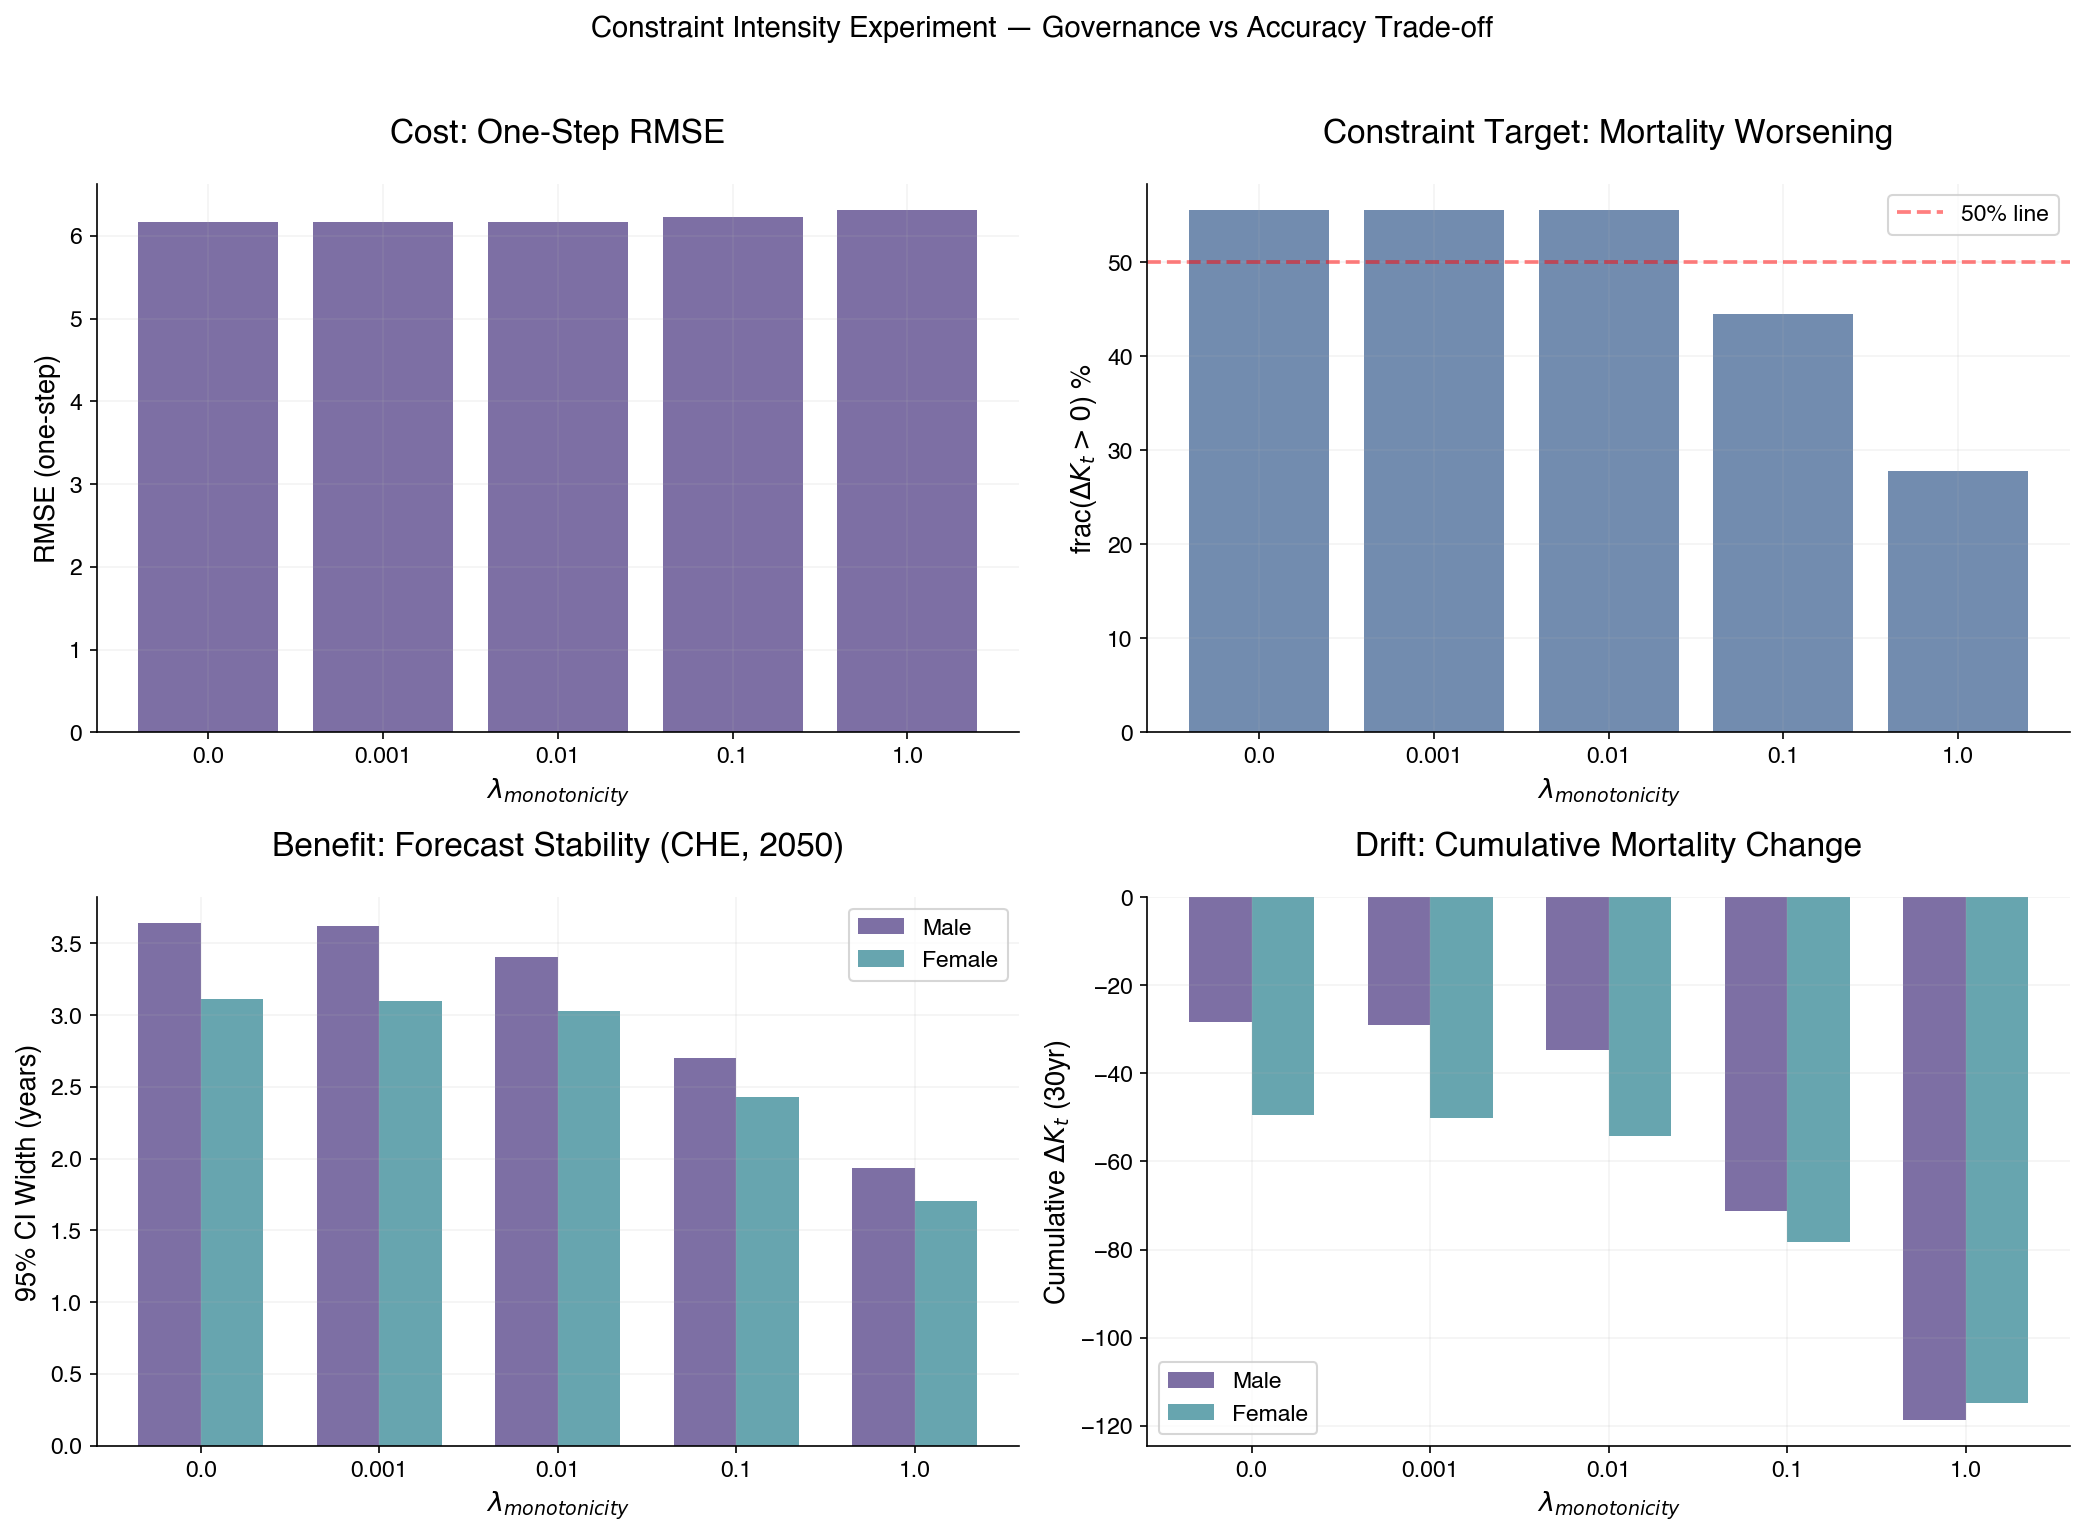

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

lambdas = df['λ_mono'].values
x_labels = [str(l) for l in lambdas]
x_pos = range(len(lambdas))

# RMSE
ax = axes[0, 0]
ax.bar(x_pos, df['RMSE'].values, color=COUNTRY_COLORS['CHE'], alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('$\\lambda_{monotonicity}$')
ax.set_ylabel('RMSE (one-step)')
ax.set_title('Cost: One-Step RMSE')

# frac(ΔKt > 0)
ax = axes[0, 1]
ax.bar(x_pos, [r * 100 for r in df['frac_pos'].values], color=COUNTRY_COLORS['SWE'], alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('$\\lambda_{monotonicity}$')
ax.set_ylabel('frac($\\Delta K_t > 0$) %')
ax.set_title('Constraint Target: Mortality Worsening')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% line')
ax.legend()

# CI width (Male + Female)
ax = axes[1, 0]
w = 0.35
ax.bar([p - w/2 for p in x_pos], df['CI_M'].values, w, label='Male', color=COUNTRY_COLORS['CHE'], alpha=0.7)
ax.bar([p + w/2 for p in x_pos], df['CI_F'].values, w, label='Female', color=COUNTRY_COLORS['NOR'], alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('$\\lambda_{monotonicity}$')
ax.set_ylabel('95% CI Width (years)')
ax.set_title('Benefit: Forecast Stability (CHE, 2050)')
ax.legend()

# Cumulative drift
ax = axes[1, 1]
ax.bar([p - w/2 for p in x_pos], df['drift_M'].values, w, label='Male', color=COUNTRY_COLORS['CHE'], alpha=0.7)
ax.bar([p + w/2 for p in x_pos], df['drift_F'].values, w, label='Female', color=COUNTRY_COLORS['NOR'], alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('$\\lambda_{monotonicity}$')
ax.set_ylabel('Cumulative $\\Delta K_t$ (30yr)')
ax.set_title('Drift: Cumulative Mortality Change')
ax.legend()

fig.suptitle('Constraint Intensity Experiment — Governance vs Accuracy Trade-off', fontsize=14, y=1.02)
plt.tight_layout()
save_dual(fig, 'fig21_constraint_intensity_experiment')
plt.show()

## 9.5: Conclusion

In [6]:
# Find the λ with the best CI/RMSE trade-off
df['trade_off'] = (baseline_ci_m - df['CI_M']) / (df['RMSE'] - baseline_rmse + 0.001)  # CI reduction per unit RMSE cost

print('='*80)
print('CONCLUSION: Constraint Intensity Trade-off')
print('='*80)
print()
print('The experiment measures the AINN monotonicity constraint\'s effect across')
print('5 intensity levels on both one-step accuracy (RMSE) and 30-year forecast')
print('stability (CI width, cumulative drift).')
print()

# Determine if any λ > 0 reduces CI
best_ci_m = df.loc[df['CI_M'].idxmin()]
best_ci_f = df.loc[df['CI_F'].idxmin()]
print(f'Best CI (Male):   λ={best_ci_m["λ_mono"]}, CI={best_ci_m["CI_M"]:.3f} '
      f'(vs baseline {baseline_ci_m:.3f}, change={best_ci_m["CI_M_vs_base"]})')
print(f'Best CI (Female): λ={best_ci_f["λ_mono"]}, CI={best_ci_f["CI_F"]:.3f} '
      f'(vs baseline {baseline_ci_f:.3f}, change={best_ci_f["CI_F_vs_base"]})')
print()

# frac(ΔKt>0) trend
frac_unconstrained = df.loc[df['λ_mono'] == 0.0, 'frac_pos'].values[0]
frac_max = df.loc[df['λ_mono'] == 1.0, 'frac_pos'].values[0]
print(f'frac(ΔKt>0): {frac_unconstrained:.1%} (λ=0) → {frac_max:.1%} (λ=1.0)')
print()

# Save results
df.to_csv(os.path.join(PROCESSED_DIR, 'constraint_intensity_experiment.csv'), index=False)
print(f'Results saved to {PROCESSED_DIR}constraint_intensity_experiment.csv')
print(f'\nNotebook 09 complete.')

CONCLUSION: Constraint Intensity Trade-off

The experiment measures the AINN monotonicity constraint's effect across
5 intensity levels on both one-step accuracy (RMSE) and 30-year forecast
stability (CI width, cumulative drift).

Best CI (Male):   λ=1.0, CI=1.934 (vs baseline 3.638, change=-46.8%)
Best CI (Female): λ=1.0, CI=1.708 (vs baseline 3.109, change=-45.1%)

frac(ΔKt>0): 55.6% (λ=0) → 27.8% (λ=1.0)

Results saved to ../data/processed/constraint_intensity_experiment.csv

Notebook 09 complete.
